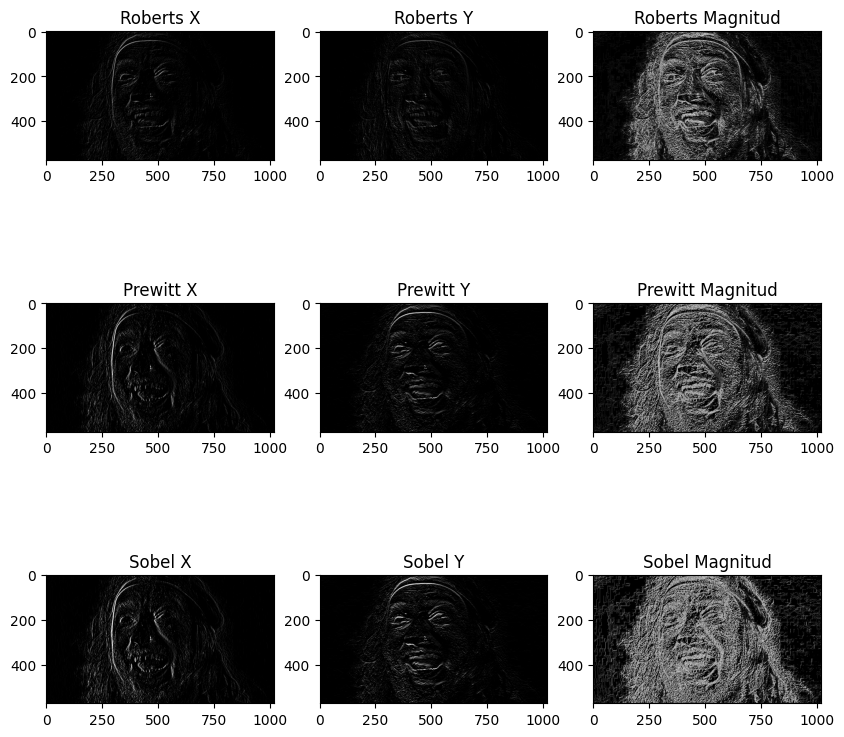

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('bananero.jpg')
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
robertx=np.array([[-1,0],[0,1]])
roberty=np.array([[0,-1],[1,0]])
robx_img=cv2.filter2D(gray,-1,robertx)
roby_img=cv2.filter2D(gray,-1,roberty)
rob_grad=np.sqrt(robx_img**2+roby_img**2)
rob_grad_dir=np.arctan2(roby_img,robx_img)

#pewit

prewitt_x=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y=np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
prex_img=cv2.filter2D(gray,-1,prewitt_x)
prey_img=cv2.filter2D(gray,-1,prewitt_y)
prewitt_mag=np.sqrt(prex_img**1+prey_img**2)
preww_dir=np.arctan2(prex_img,prey_img)

# solbel

sobel_x=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y=np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
sobelx_img=cv2.filter2D(gray,-1,sobel_x)
sobely_img=cv2.filter2D(gray,-1,sobel_y)
sobel_mag=np.sqrt(sobelx_img**2+sobely_img**2)
sobel_dir=np.arctan2(sobely_img,sobelx_img)

cany_img=cv2.Canny(gray,100,100)

plt.figure(figsize=(10,10))

plt.subplot(331)
plt.imshow(robx_img, cmap='gray')
plt.title('Roberts X')

plt.subplot(332)
plt.imshow(roby_img, cmap='gray')
plt.title('Roberts Y')

plt.subplot(333)
plt.imshow(rob_grad, cmap='gray')
plt.title('Roberts Magnitud')

plt.subplot(334)
plt.imshow(prex_img, cmap='gray')
plt.title('Prewitt X')

plt.subplot(335)
plt.imshow(prey_img, cmap='gray')
plt.title('Prewitt Y')

plt.subplot(336)
plt.imshow(prewitt_mag, cmap='gray')
plt.title('Prewitt Magnitud')

plt.subplot(337)
plt.imshow(sobelx_img, cmap='gray')
plt.title('Sobel X')

plt.subplot(338)
plt.imshow(sobely_img, cmap='gray')
plt.title('Sobel Y')

plt.subplot(339)
plt.imshow(sobel_mag, cmap='gray')
plt.title('Sobel Magnitud')

plt.show()

SOBEL

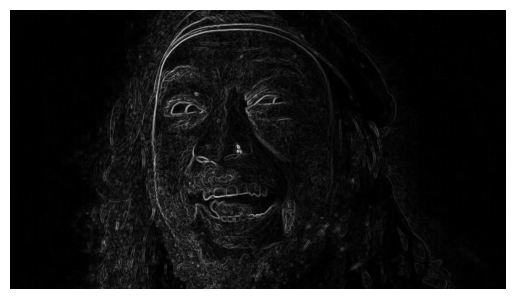

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    g_x=cv2.Sobel(img_gris,cv2.CV_64F,1,0,ksize=3)
    g_y=cv2.Sobel(img_gris,cv2.CV_64F,0,1,ksize=3)

    mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    return mag
img = cv2.imread('bananero.jpg')
resultado = filtro_sobel(img)

plt.imshow(resultado, cmap='gray')
plt.axis('off')
plt.show()

SOBEL MEJORADO

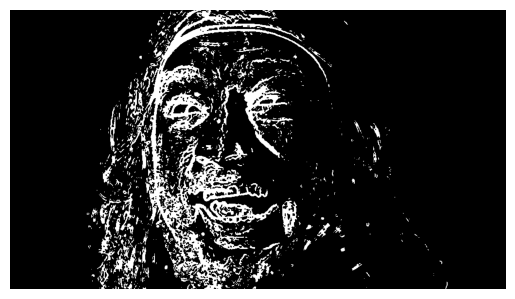

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img,kernel_size=3,umbral=30):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    #para mejorar la deteccion filtro gauss
    img_gris=cv2.GaussianBlur(img_gris,(3,3),0)

    g_x=cv2.Sobel(img_gris,cv2.CV_64F,1,0,ksize=3)
    g_y=cv2.Sobel(img_gris,cv2.CV_64F,0,1,ksize=3)
    
    
    #mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=np.sqrt(g_x**2+g_y**2)
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _,bordes=cv2.threshold(mag,umbral,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    kernel_m=np.ones((2,2),np.uint8)
    bordes=cv2.morphologyEx(bordes,cv2.MORPH_CLOSE,kernel_m)
    return bordes


img = cv2.imread('bananero.jpg')
resultado = filtro_sobel_mejorado(img)

plt.imshow(resultado, cmap='gray')
plt.axis('off')
plt.show()

Robert

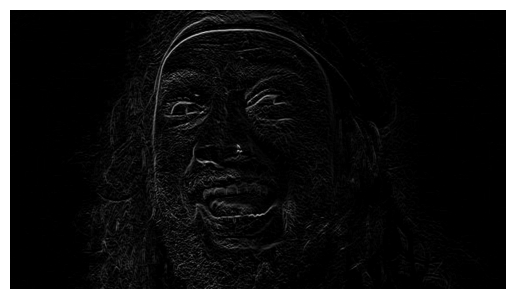

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    robertx=np.array([[-1,0],[0,1]],dtype=np.float32)
    roberty=np.array([[0,-1],[1,0]],dtype=np.float32)
    r_x=cv2.filter2D(img_gris,-1,robertx)
    r_y=cv2.filter2D(img_gris,-1,roberty)
    roberts=cv2.addWeighted(r_x,0.5,r_y,0.5,0)
    return roberts

img = cv2.imread('bananero.jpg')
resultado = filtro_roberts(img)

plt.imshow(resultado, cmap='gray')
plt.axis('off')
plt.show()
